  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


Saving S-KNGM-GM-3_T_133820_0.las to S-KNGM-GM-3_T_133820_0 (1).las
               CALI            DT            GR           LLD           LLS  \
count  14384.000000  14308.000000  14385.000000  14384.000000  14384.000000   
mean      13.373767    138.115603     55.925115     41.024014      1.573854   
std        4.240997     34.696602     15.549509   1230.469880      2.241097   
min        3.119300     36.298800     14.963400      0.101100      0.165500   
25%        8.816675    106.900200     46.072100      1.205100      1.093750   
50%       12.936900    136.255100     56.692900      1.377950      1.214550   
75%       16.578750    168.627175     67.279300      2.004925      1.708600   
max       22.706300    201.171900    156.428900  40000.000000     95.222500   

               MSFL          NPHI          RHOB            SP  
count  14385.000000  11309.000000  11309.000000  14384.000000  
mean       2.924100      0.435598      2.217222    -15.335110  
std       27.600219      0.1

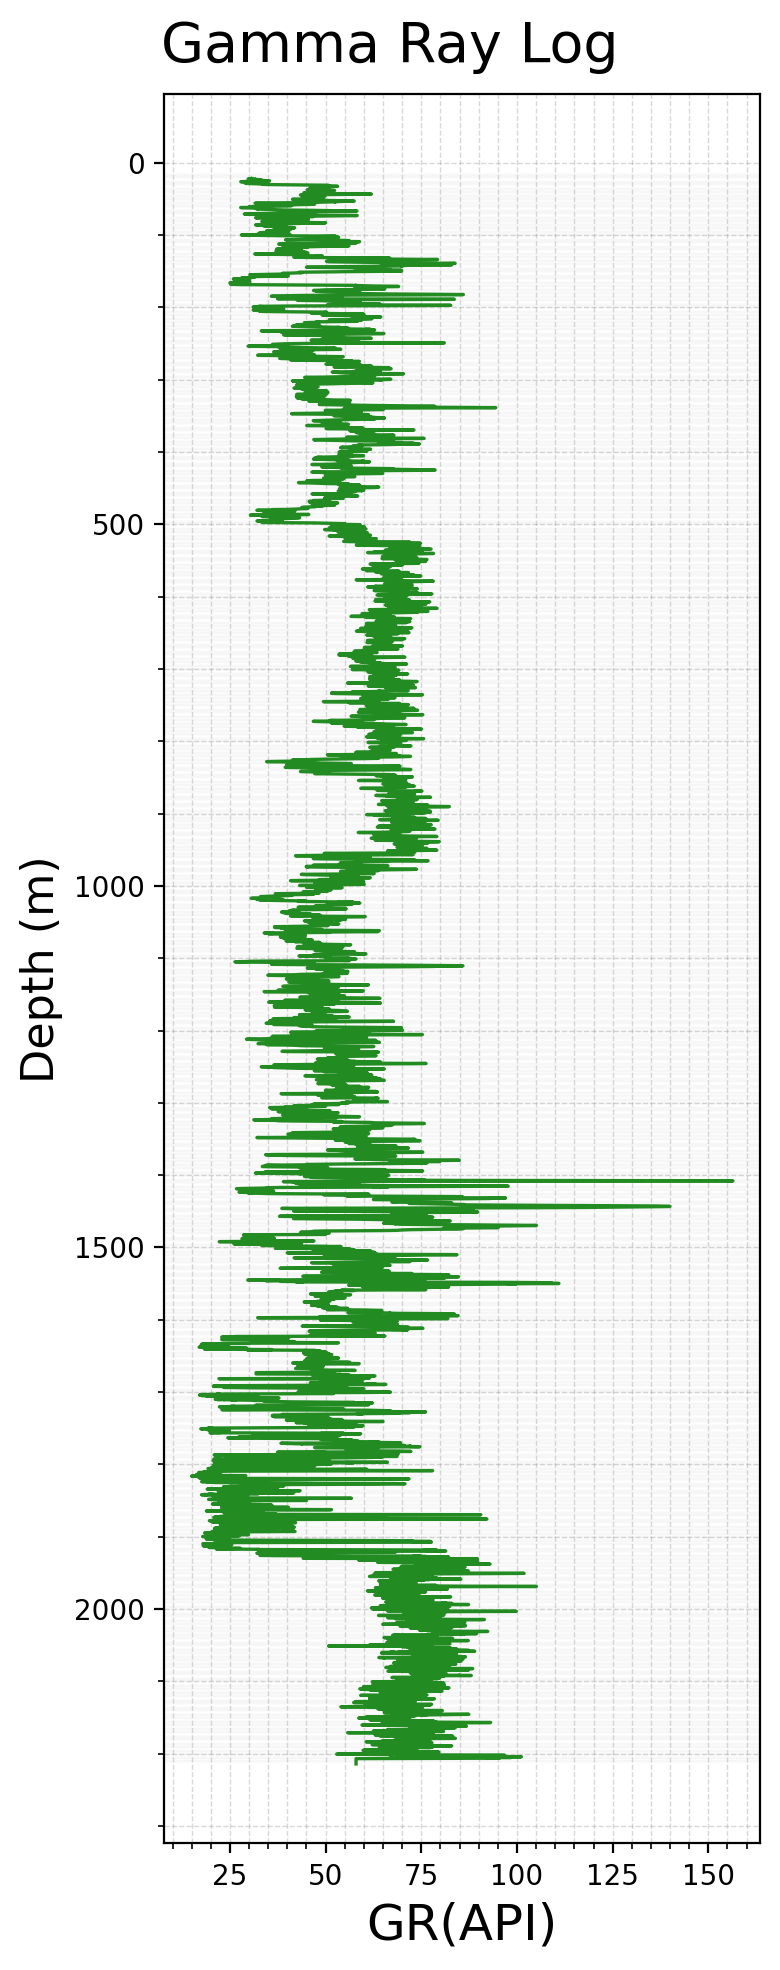

In [8]:
!pip install lasio pandas numpy matplotlib sklearn seaborn
import lasio as las
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
well=las.read(r'S-KNGM-GM-3_T_133820_0.las')


well7=well.df()

well7.columns
print(well7.describe())


pd.set_option('display.min_rows',500)

fig_GR= plt.figure(figsize=(4,10),dpi=200)

plt.plot(well7.GR, well7.index, color='forestgreen', linewidth=1.2)

plt.gca().invert_yaxis()

fig_GR.suptitle('Gamma Ray Log', fontsize=20)

plt.xlabel('GR(API)', fontsize=18)
plt.ylabel('Depth (m)', fontsize=16)

plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
plt.minorticks_on()
plt.tight_layout()
for y in np.arange(well7.index.min(), well7.index.max(), 10):  # every 10m
    plt.axhspan(y, y + 5, color='lightgray', alpha=0.1)


Text(0, 0.5, 'Depth (m)')

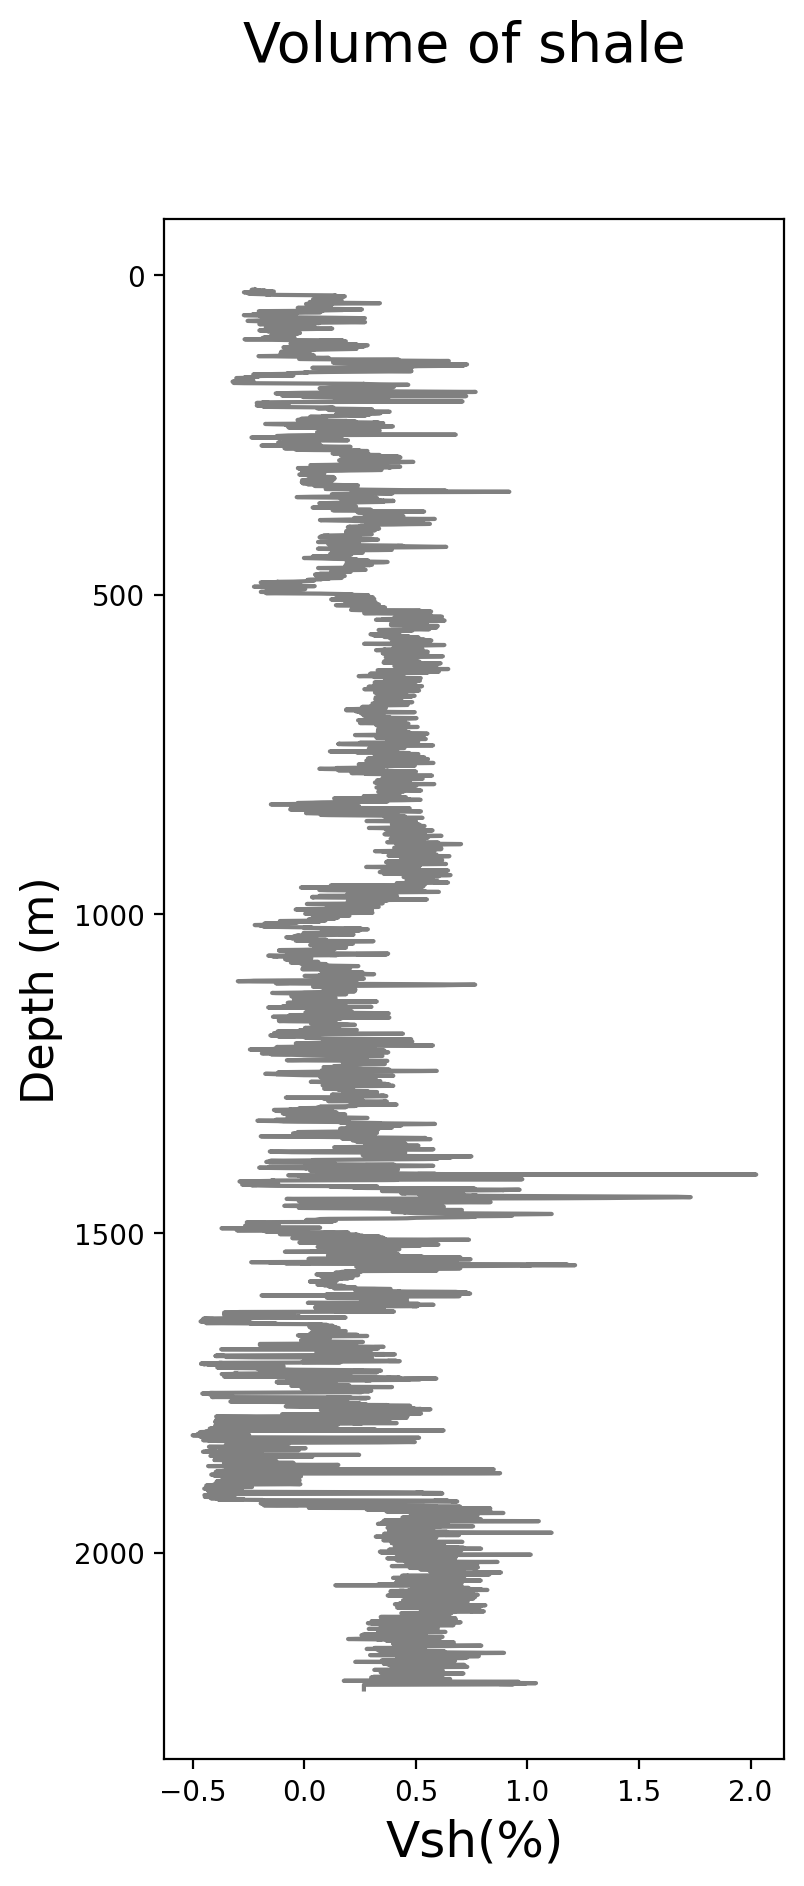

In [9]:
well7['Vsh']=(well7.GR-43)/(99-43)

well7.Vsh

fig_Vsh= plt.figure(figsize=(4,10),dpi=200)

plt.plot(well7.Vsh, well7.index, color='grey')

plt.gca().invert_yaxis()

fig_Vsh.suptitle('Volume of shale', fontsize=20)

plt.xlabel('Vsh(%)', fontsize=18)

plt.ylabel('Depth (m)', fontsize=16)

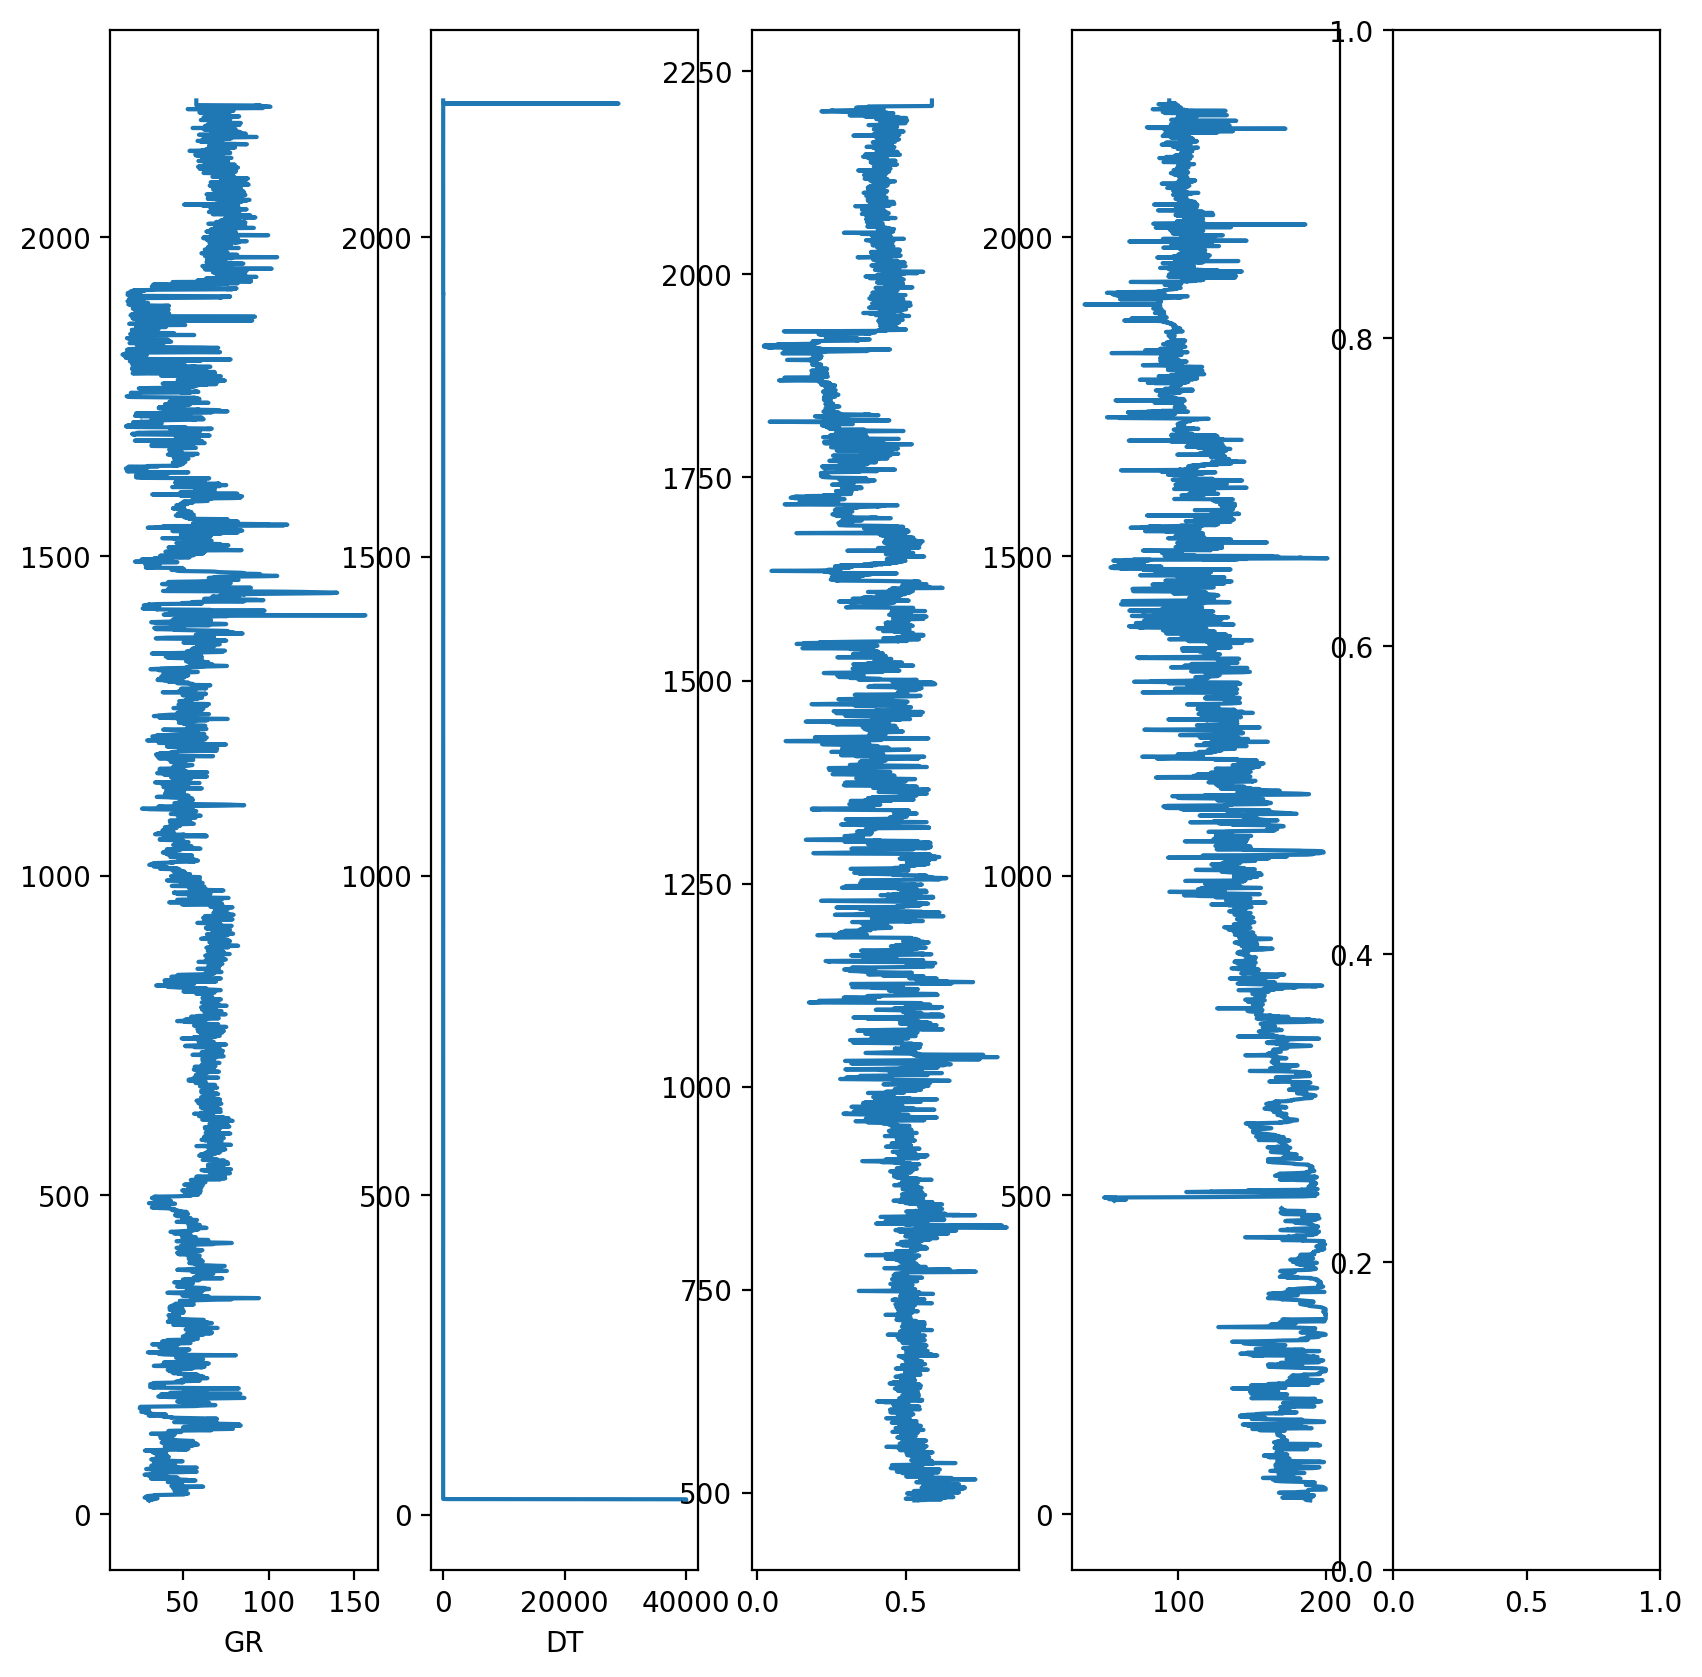

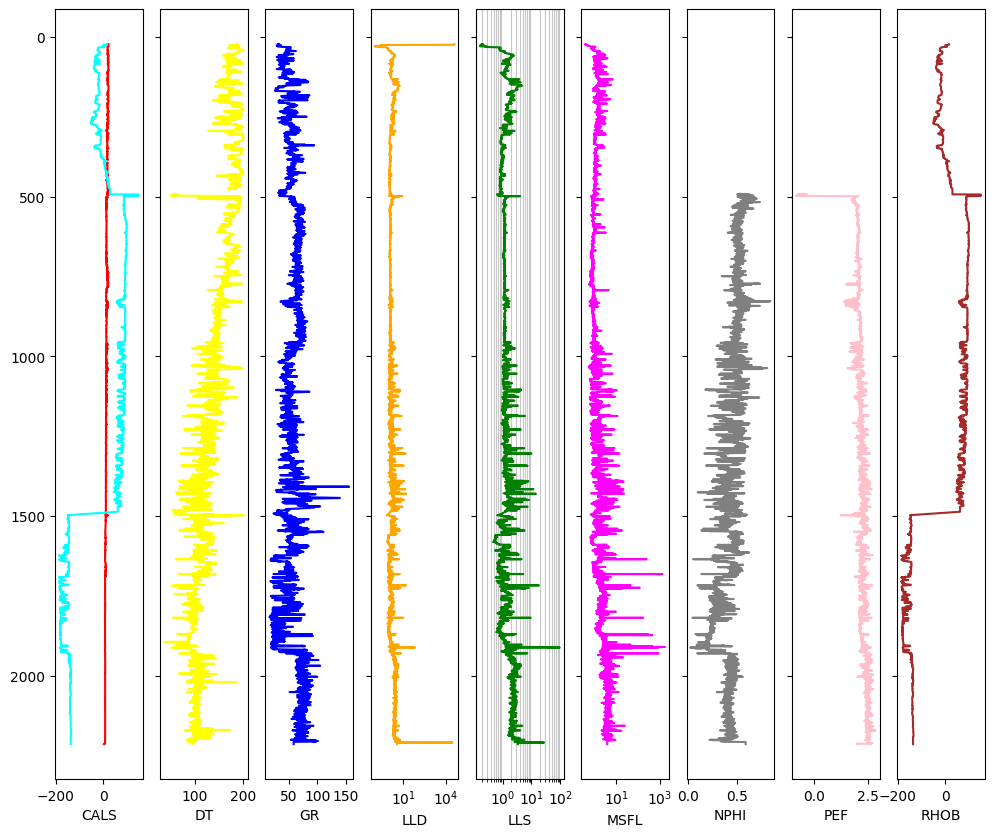

In [10]:
fig,axes=plt.subplots(nrows=1,ncols=5, figsize=(10,10),dpi=200)

axes[0].plot(well7.GR,well7.index);axes[0].set_xlabel('GR')

axes[1].plot(well7.LLD,well7.index);axes[1].set_xlabel('LLD')

axes[2].plot(well7.NPHI,well7.index);axes[1].set_xlabel('NPHI')

axes[3].plot(well7.DT,well7.index);axes[1].set_xlabel('DT')


fig,axes = plt.subplots(nrows=1,ncols=9,figsize=(12,10),sharey=True)

logs=['CALS','DT','GR','LLD','LLS','MSFL','NPHI','PEF','RHOB','SP']

axes[0].plot(list(well7.CALI),list(well7.index),'red')

axes[0].plot(list(well7.SP),list(well7.index),'cyan')

axes[1].plot(list(well7.DT),list(well7.index),'yellow')

axes[2].plot(list(well7.GR),list(well7.index),'blue')

axes[3].semilogx(list(well7.LLD),list(well7.index),'orange')

axes[4].semilogx(list(well7.LLS),list(well7.index),'green')

axes[5].semilogx(list(well7.MSFL),list(well7.index),'magenta')

axes[6].plot(list(well7.NPHI),list(well7.index),'grey')

axes[7].plot(list(well7.RHOB),list(well7.index),'pink')

axes[8].plot(list(well7.SP),list(well7.index),'brown')

axes[0].invert_yaxis()

for i in range(9):
  axes[i].set_xlabel(logs[i])
  axes[i].grid(which='minor', alpha=0.7)

In [11]:
start=1000

end=1200

start_index=0

end_index=0

for i in range(len(list(well7.index))):
  if(list(well7.index)[i]>=start):
    start_index=i
    break

for i in range(len(list(well7.index))):
  if(list(well7.index)[i]>=end):
    end_index=i
    break

#print(start_index,end_index)

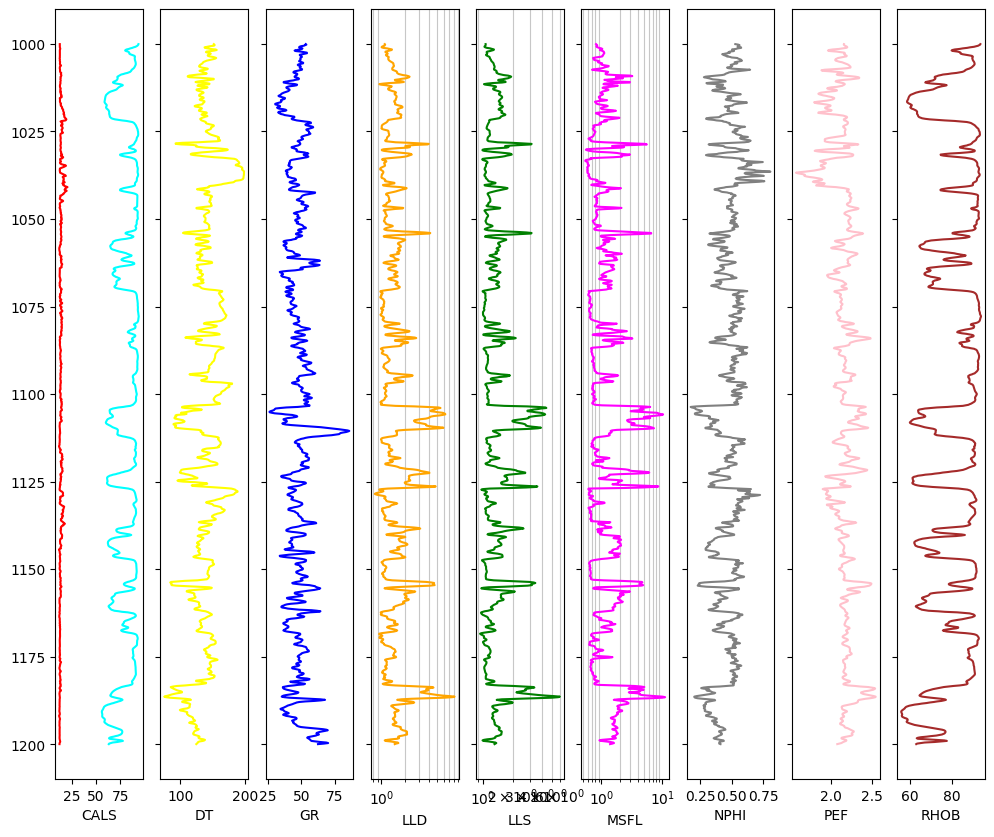

In [12]:
fig,axes = plt.subplots(nrows=1,ncols=9,figsize=(12,10),sharey=True)

logs=['CALS','DT','GR','LLD','LLS','MSFL','NPHI','PEF','RHOB','SP']

axes[0].plot(list(well7.CALI)[start_index:end_index],list(well7.index)[start_index:end_index],'red')

axes[0].plot(list(well7.SP)[start_index:end_index],list(well7.index)[start_index:end_index],'cyan')

axes[1].plot(list(well7.DT)[start_index:end_index],list(well7.index)[start_index:end_index],'yellow')

axes[2].plot(list(well7.GR)[start_index:end_index],list(well7.index)[start_index:end_index],'blue')

axes[3].semilogx(list(well7.LLD)[start_index:end_index],list(well7.index)[start_index:end_index],'orange')

axes[4].semilogx(list(well7.LLS)[start_index:end_index],list(well7.index)[start_index:end_index],'green')

axes[5].semilogx(list(well7.MSFL)[start_index:end_index],list(well7.index)[start_index:end_index],'magenta')

axes[6].plot(list(well7.NPHI)[start_index:end_index],list(well7.index)[start_index:end_index],'grey')

axes[7].plot(list(well7.RHOB)[start_index:end_index],list(well7.index)[start_index:end_index],'pink')

axes[8].plot(list(well7.SP)[start_index:end_index],list(well7.index)[start_index:end_index],'brown')

axes[0].invert_yaxis()

for i in range(9):
  axes[i].set_xlabel(logs[i])
  axes[i].grid(which='minor', alpha=0.7)

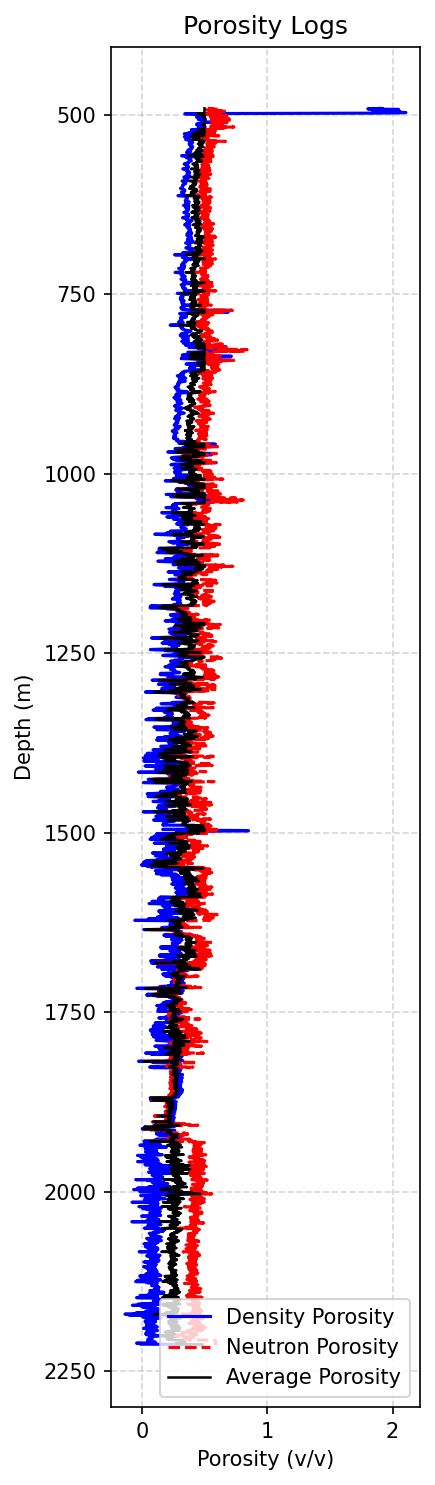

In [13]:
matrix_density = 2.65  # g/cc (sandstone)
fluid_density = 1.0    # g/cc (freshwater)

# Compute density porosity
well7['PHI_D'] = (matrix_density - well7['RHOB']) / (matrix_density - fluid_density)

# Neutron porosity from NPHI (usually already in porosity units)
well7['PHI_N'] = well7['NPHI']

# Combined porosity (simple average, or choose based on lithology)
well7['PHI_TOTAL'] = (well7['PHI_D'] + well7['PHI_N']) / 2

# Optional: clip unrealistic values
well7['PHI_TOTAL'] = well7['PHI_TOTAL'].clip(lower=0, upper=0.5)

# Plot porosity log
fig, ax = plt.subplots(figsize=(3,10), dpi=150)

ax.plot(well7['PHI_D'], well7.index, label='Density Porosity', color='blue')
ax.plot(well7['PHI_N'], well7.index, label='Neutron Porosity', color='red', linestyle='--')
ax.plot(well7['PHI_TOTAL'], well7.index, label='Average Porosity', color='black', linewidth=1.2)

ax.invert_yaxis()
ax.set_xlabel("Porosity (v/v)")
ax.set_ylabel("Depth (m)")
ax.set_title("Porosity Logs")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()

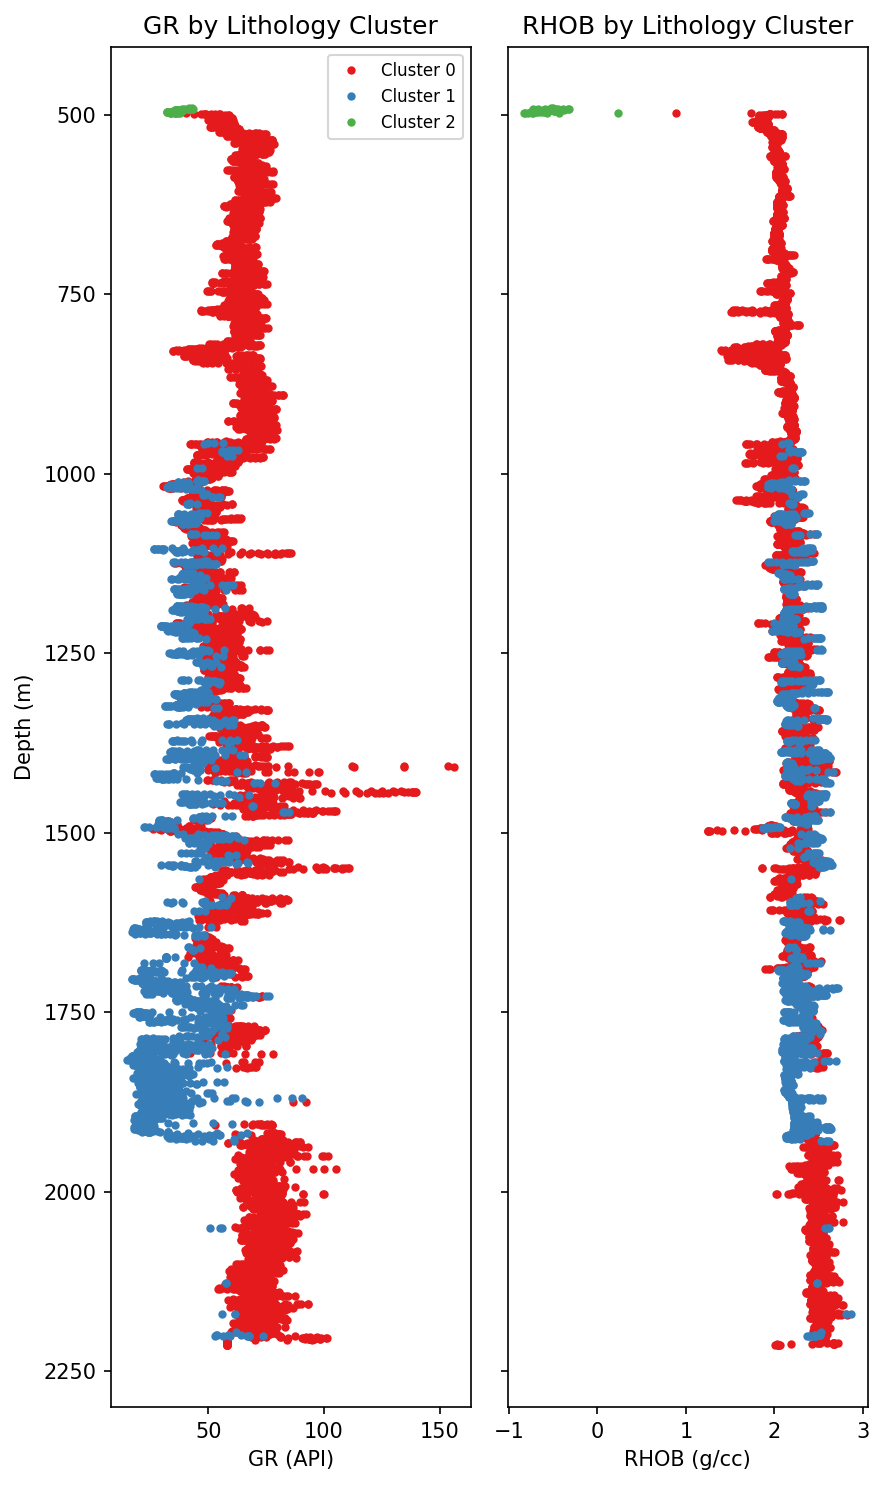

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

# Step 1: Choose features relevant to lithology
features = ['GR', 'RHOB', 'NPHI']
data = well7[features].dropna()

# Step 2: Normalize (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Step 3: Fit KMeans (choose n_clusters=3 for sand, shale, carbonate)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the original dataframe
well7 = well7.loc[data.index]
well7['LITHO_CLUSTER'] = clusters

# Step 4: Plot GR and RHOB with lithology coloring
fig, axs = plt.subplots(1, 2, figsize=(6, 10), dpi=150, sharey=True)

colors = sns.color_palette("Set1", n_colors=3)

for i in range(3):
    mask = well7['LITHO_CLUSTER'] == i
    axs[0].plot(well7.loc[mask, 'GR'], well7.loc[mask].index, '.', label=f'Cluster {i}', color=colors[i])
    axs[1].plot(well7.loc[mask, 'RHOB'], well7.loc[mask].index, '.', color=colors[i])

axs[0].invert_yaxis()
axs[0].set_xlabel("GR (API)")
axs[1].set_xlabel("RHOB (g/cc)")
axs[0].set_ylabel("Depth (m)")

axs[0].legend(fontsize=8)
axs[0].set_title("GR by Lithology Cluster")
axs[1].set_title("RHOB by Lithology Cluster")

plt.tight_layout()
plt.show()


In [16]:
# Step 1: Select features (no PEF)
features = ['GR', 'RHOB', 'NPHI']
data = well7[features].dropna()

# Step 2: Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Step 3: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Step 4: Add cluster labels back
well7 = well7.loc[data.index]
well7['LITHO_CLUSTER'] = clusters

# Step 5: Analyze clusters (to map them later)
cluster_means = well7.groupby('LITHO_CLUSTER')[['GR', 'RHOB']].mean().sort_values(by='GR')
print(cluster_means)

# Step 6: Map clusters to lithology based on GR & RHOB
sorted_clusters = cluster_means.index.tolist()
litho_labels = ['Sandstone', 'Carbonate', 'Shale']
cluster_to_litho = dict(zip(sorted_clusters, litho_labels))

well7['LITHO_PRED'] = well7['LITHO_CLUSTER'].map(cluster_to_litho)


                      GR      RHOB
LITHO_CLUSTER                     
2              37.217335 -0.576887
1              37.604704  2.249700
0              63.800022  2.222165


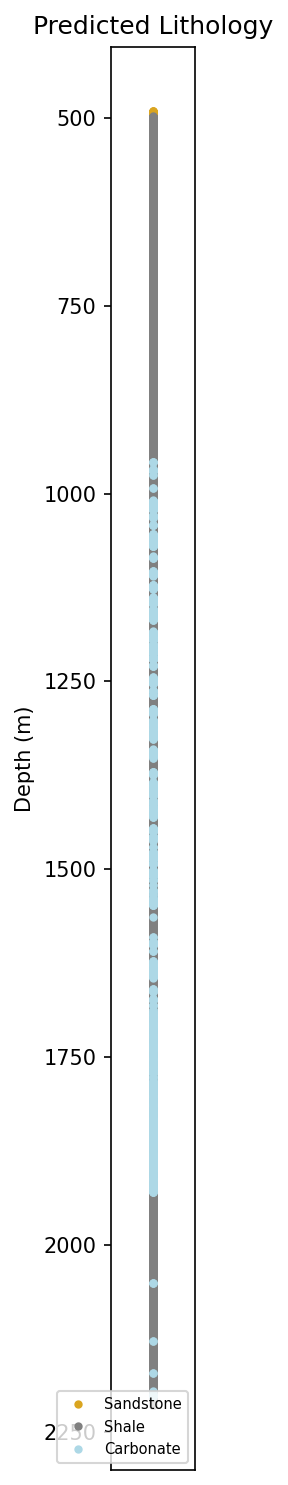

In [17]:
fig, ax = plt.subplots(figsize=(1.5, 10), dpi=150)

colors = {'Sandstone': 'goldenrod', 'Shale': 'gray', 'Carbonate': 'lightblue'}
for lith in colors:
    mask = well7['LITHO_PRED'] == lith
    ax.plot([1]*mask.sum(), well7[mask].index, '.', color=colors[lith], label=lith)

ax.invert_yaxis()
ax.set_xticks([])
ax.set_title("Predicted Lithology")
ax.set_ylabel("Depth (m)")
ax.legend(loc='lower right', fontsize=7)

plt.tight_layout()


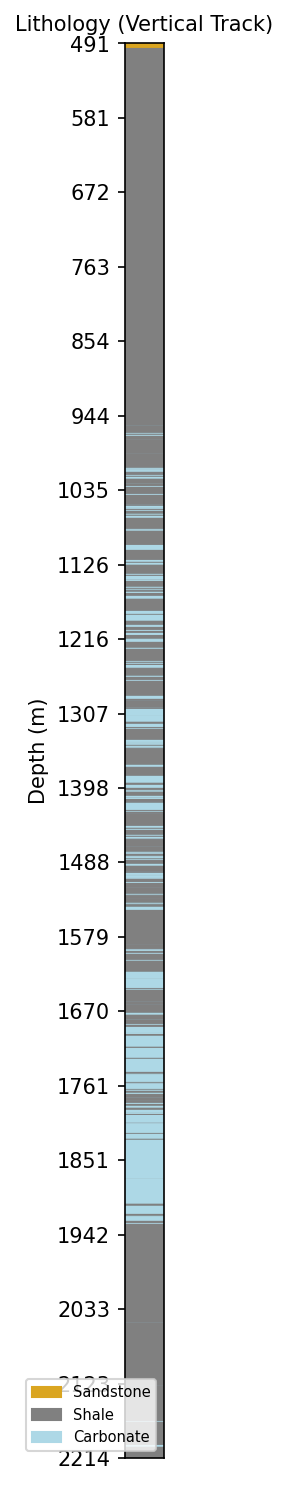

In [18]:
import matplotlib.patches as mpatches

# Define colors for each predicted lithology
litho_colors = {
    'Sandstone': 'goldenrod',
    'Shale': 'gray',
    'Carbonate': 'lightblue'
}

# Create figure
fig, ax = plt.subplots(figsize=(1.2, 10), dpi=150)

# Get depth and lithology
depths = well7.index.to_numpy()
lithologies = well7['LITHO_PRED'].to_numpy()

# Plot colored rectangles
for i in range(len(depths) - 1):
    top = depths[i]
    bottom = depths[i + 1]
    lith = lithologies[i]
    color = litho_colors.get(lith, 'white')
    ax.add_patch(mpatches.Rectangle((0, bottom), 1, top - bottom, color=color))

# Beautify
ax.set_ylim(depths.max(), depths.min())
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticks(np.linspace(depths.min(), depths.max(), 20))
ax.set_ylabel('Depth (m)')
ax.set_title('Lithology (Vertical Track)', fontsize=10)

# Legend
legend_handles = [mpatches.Patch(color=color, label=label) for label, color in litho_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7)

plt.tight_layout()